# Подготовка поднабора StreamSafe из 500 трасс

Ноутбук проверяет публичные агрегаты нормализации и выбора. Исходные запросы и ответы здесь не загружаются и не выводятся. Точная граница вреда требует ручного аудита; автоматический интервал не считается ручной разметкой.

In [1]:
from pathlib import Path
import json
import platform

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
tables_dir = root / 'reports' / 'tables'
figures_dir = root / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
print(f'Python: {platform.python_version()}')

Python: 3.11.14


## 1. Происхождение и воспроизводимость

Манифесты фиксируют ревизии StreamSafe и токенизатора Qwen, параметры выбора и контрольные суммы.

In [2]:
pool_manifest = json.loads((root / 'data/processed/streamsafe_pool_manifest.json').read_text())
subset_manifest = json.loads((root / 'data/processed/streamsafe_subset_manifest.json').read_text())
print('Ревизия StreamSafe:', pool_manifest['dataset_revision'])
print('Ревизия токенизатора:', pool_manifest['tokenizer_revision'])
print('Токенные координаты заполнены:', pool_manifest['token_coordinates_complete'])
print('Трасс в пуле:', pool_manifest['trace_count'])
print('Трасс в поднаборе:', subset_manifest['trace_count'])
print('SHA-256 поднабора:', subset_manifest['parquet_sha256'])

Ревизия StreamSafe: 16d0ff1f42e980bb99bd36125583361b15c664e3
Ревизия токенизатора: 419364a715de9840d47b1457982f64ff37f90ed4
Токенные координаты заполнены: True
Трасс в пуле: 2963
Трасс в поднаборе: 500
SHA-256 поднабора: 6cb10701bc27f1641cb0d61b565d668748f33bf5d6b7ba1b7ea942f514eea0bb


## 2. Нормализация и исключения

Префикс связывается с полным ответом только при однозначном совпадении части данных, запроса, режима ответа и исходного текста. Большое число несопоставленных строк — не удаление данных: это записи, для которых строгую связь нельзя доказать по доступным полям StreamSafe. Полный журнал остаётся локальным, публично сохраняется только агрегат.

In [3]:
issue_summary = pd.read_csv(tables_dir / 'normalization_issue_summary.csv')
issue_summary

,split,table_kind,code,count
0,train,partial,ambiguous_prefix,292
1,train,partial,unmatched_prefix,35389
2,val,partial,ambiguous_prefix,5
3,val,partial,unmatched_prefix,2145


## 3. Проверка состава поднабора

Все заявленные квоты должны иметь статус `pass`. Части `train` и `val` сохраняются раздельно и в дальнейшей оценке не объединяются.

In [4]:
validation = pd.read_csv(tables_dir / 'subset_validation.csv')
distribution = pd.read_csv(tables_dir / 'subset_distribution.csv')
print('Проваленных проверок:', int((validation['status'] != 'pass').sum()))
validation

Проваленных проверок: 0


,check,status,actual,expected,details
0,total_traces,pass,500,500,"required eq 500, observed 500"
1,unique_trace_ids,pass,500,500,"required eq 500, observed 500"
2,train_safe,pass,200,200,"required eq 200, observed 200"
3,train_unsafe,pass,200,200,"required eq 200, observed 200"
4,val_safe,pass,50,50,"required eq 50, observed 50"
5,val_unsafe,pass,50,50,"required eq 50, observed 50"
6,safe_length_short,pass,84,60,"required ge 60, observed 84"
7,safe_length_medium,pass,83,60,"required ge 60, observed 83"
8,safe_length_long,pass,83,60,"required ge 60, observed 83"
9,unsafe_onset_early,pass,155,120,"required ge 120, observed 155"


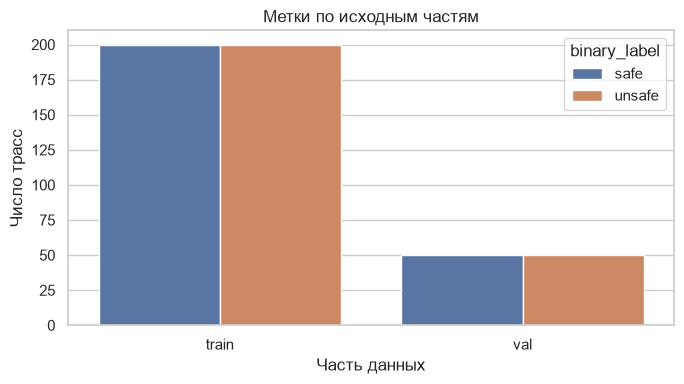

In [5]:
labels = distribution[distribution['dimension'] == 'source_split+binary_label'].copy()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=labels, x='source_split', y='count', hue='binary_label', ax=ax)
ax.set(title='Метки по исходным частям', xlabel='Часть данных', ylabel='Число трасс')
fig.tight_layout()
fig.savefig(figures_dir / 'subset_labels_by_split.png', dpi=160)
plt.show()

## 4. Позиция появления вреда

Для каждой опасной трассы берётся конец первого префикса с меткой `unsafe` и делится на длину полного ответа. `early` означает не более 33%, `middle` — от 33% до 66%, `late` — более 66%. Это положение верхней границы интервала, а не точного первого опасного символа.

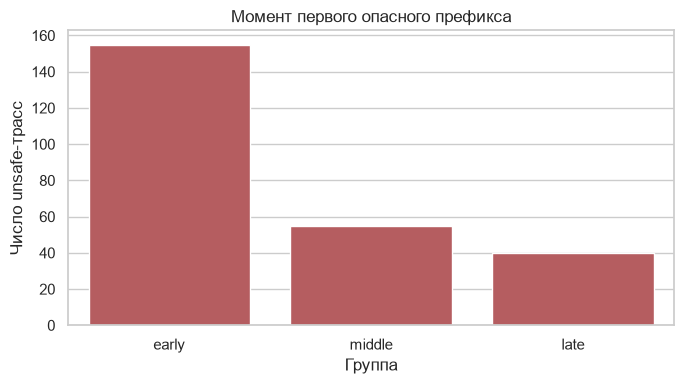

In [6]:
onset = distribution[distribution['dimension'] == 'unsafe_onset_bucket'].copy()
order = ['early', 'middle', 'late']
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=onset, x='onset_bucket', y='count', order=order, color='#c44e52', ax=ax)
ax.set(title='Момент первого опасного префикса', xlabel='Группа', ylabel='Число unsafe-трасс')
fig.tight_layout()
fig.savefig(figures_dir / 'subset_onset_buckets.png', dpi=160)
plt.show()

## 5. Категории вреда

Категории многометочные: одна трасса может учитываться в нескольких строках, поэтому сумма столбцов может быть больше 250. Редкие категории сохраняются полностью, если доступно менее пяти трасс.

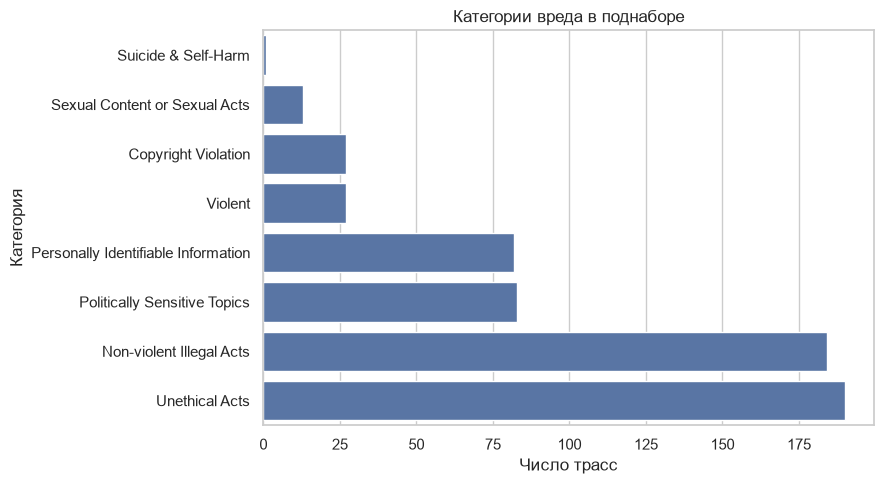

In [7]:
categories = distribution[distribution['dimension'] == 'harm_category'].sort_values('count')
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=categories, x='count', y='harm_category', color='#4c72b0', ax=ax)
ax.set(title='Категории вреда в поднаборе', xlabel='Число трасс', ylabel='Категория')
fig.tight_layout()
fig.savefig(figures_dir / 'subset_categories.png', dpi=160)
plt.show()

## 6. Пересечения частей данных

Сравниваются точные запросы, ответы, пары и версия ответа без технических тегов тестовой части. Отчёт хранит только хэши и идентификаторы. Совпадение не удаляется автоматически: его должен оценить рецензент.

In [8]:
overlap = pd.read_csv(tables_dir / 'split_overlap_summary.csv')
overlap

,left_split,right_split,comparison,shared_values,left_rows,right_rows
0,train,val,prompt_hash,5,18,9
1,train,val,response_hash,1,1,1
2,train,val,pair_hash,1,1,1
3,train,val,canonical_response_hash,1,1,1
4,train,test,prompt_hash,90,143,271
5,train,test,response_hash,0,0,0
6,train,test,pair_hash,0,0,0
7,train,test,canonical_response_hash,0,0,0
8,val,test,prompt_hash,3,3,13
9,val,test,response_hash,0,0,0


## 7. Ручной аудит

Код выбрал 50 безопасных и 50 опасных записей. Для опасных соблюдены квоты ранних, средних и поздних случаев. Поля рецензента остаются пустыми до реальной проверки человеком.

In [9]:
audit = pd.read_csv(tables_dir / 'manual_audit_summary.csv')
for row in audit.itertuples():
    print(f'{row.metric}: {row.value}')

selected_records: 100
completed_records: 0
safe_records: 50
unsafe_records: 50
validation_issues: 0


## 8. Выводы и следующие действия

Автоматическая часть готова: поднабор имеет точный размер, баланс меток и частей, минимумы по длине, моменту вреда и категориям; токенные координаты рассчитаны закреплённым токенизатором. Ограничение StreamSafe состоит в отсутствии явного идентификатора, связывающего полный ответ с каждым префиксом, поэтому строгая нормализация сохраняет только однозначные связи.

До окончательной приёмки участнику необходимо заполнить локальный файл `data/interim/manual_audit_100.csv`, затем запустить `python scripts/validate_streamsafe_subset.py` без флага `--skip-manual`. Конфликты между ручной точкой и автоматическим интервалом должны разбираться отдельно, а не исправляться молча.